# Vanishing Gradient Problem in Neural Network

# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [4]:
from keras import Sequential
from keras.layers import Dense, Input
from keras.optimizers import SGD
from keras.activations import sigmoid
from keras.losses import BinaryCrossentropy

# Make Dataset

In [5]:
X, y = make_classification(
    n_samples=100,        # number of samples
    n_features=2,         # total number of features
    n_informative=2,       # number of informative features
    n_redundant=0,         # number of redundant features (changed from 2 to 0)
    n_repeated=0,          # no repeated features
    n_classes=2,           # binary classification
    n_clusters_per_class=2,# clusters per class
    weights=[0.5, 0.5],    # balanced classes
    class_sep=1.5,         # separation between classes
    random_state=42        # reproducibility
)

# Wrap in a DataFrame for convenience
X = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
y = pd.Series(y, name="target")

print(X.shape, y.shape)
X.head()

(100, 2) (100,)


,feature_0,feature_1
0,0.059426,2.888694
1,1.812175,-1.217315
2,-2.059849,-2.424874
3,-2.781386,0.363144
4,2.060704,-0.927958


# Plot Dataset

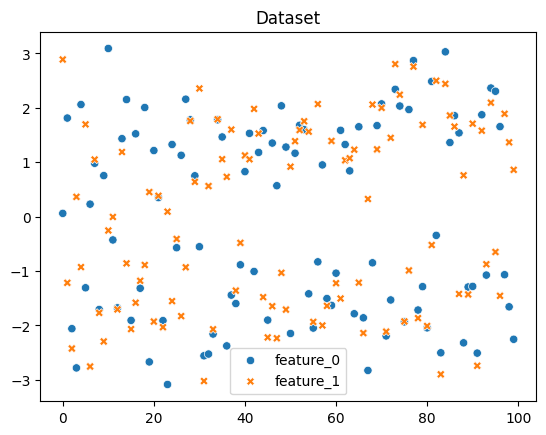

In [6]:
sns.scatterplot(data=X)
plt.title('Dataset')
plt.show()

# Train Test Split

In [7]:
X = X.values
y = y.values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale Dataset

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Build

In [10]:
my_model = Sequential()
# Input Layer
my_model.add(Input(shape=(X_train.shape[1],)))

# Hidden Layer
my_model.add(Dense(10, activation='sigmoid'))
my_model.add(Dense(10, activation='sigmoid'))
my_model.add(Dense(10, activation='sigmoid'))
my_model.add(Dense(10, activation='sigmoid'))
my_model.add(Dense(10, activation='sigmoid'))
my_model.add(Dense(10, activation='sigmoid'))
my_model.add(Dense(10, activation='sigmoid'))
my_model.add(Dense(10, activation='sigmoid'))
my_model.add(Dense(10, activation='sigmoid'))
my_model.add(Dense(10, activation='sigmoid'))
my_model.add(Dense(10, activation='sigmoid'))
my_model.add(Dense(10, activation='sigmoid'))

# Output Layer
my_model.add(Dense(1, activation='sigmoid'))

In [11]:
my_model.compile(
    optimizer=SGD(),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [12]:
my_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,251 (4.89 KB)

 Trainable params: 1,251 (4.89 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
old_weights = my_model.get_weights()[0]

In [14]:
old_weights

array([[ 0.33759528,  0.06680208,  0.11370343, -0.5849397 ,  0.6261713 ,
        -0.24709821,  0.36192745, -0.70558494, -0.15517879, -0.2715771 ],
       [ 0.51473504,  0.10335839,  0.12928784,  0.03954303,  0.3829053 ,
         0.06135267, -0.12284827,  0.25479335,  0.46977836, -0.6611696 ]],
      dtype=float32)

In [15]:
my_model.fit(X_train, y_train, epochs=10)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5617 - loss: 0.6880
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5266 - loss: 0.7008
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5734 - loss: 0.6831
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5383 - loss: 0.6958
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5578 - loss: 0.6884
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5383 - loss: 0.6951
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5539 - loss: 0.6894
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5383 - loss: 0.6945
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5422 - loss: 0.6930
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5461 - loss: 0.6915


In [16]:
new_weights = my_model.get_weights()[0]

In [17]:
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)
gradient

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

## Observation
There is no big changes

In [18]:
old_weights

array([[ 0.33759528,  0.06680208,  0.11370343, -0.5849397 ,  0.6261713 ,
        -0.24709821,  0.36192745, -0.70558494, -0.15517879, -0.2715771 ],
       [ 0.51473504,  0.10335839,  0.12928784,  0.03954303,  0.3829053 ,
         0.06135267, -0.12284827,  0.25479335,  0.46977836, -0.6611696 ]],
      dtype=float32)

In [19]:
new_weights

array([[ 0.33759528,  0.06680208,  0.11370343, -0.5849397 ,  0.6261713 ,
        -0.24709821,  0.36192745, -0.70558494, -0.15517879, -0.2715771 ],
       [ 0.51473504,  0.10335839,  0.12928784,  0.03954303,  0.3829053 ,
         0.06135267, -0.12284827,  0.25479335,  0.46977836, -0.6611696 ]],
      dtype=float32)

# Solution 1: Reduce Hidden Layers

In [20]:
my_model2 = Sequential()
# Input Layer
my_model2.add(Input(shape=(X_train.shape[1],)))

# Hidden Layer
my_model2.add(Dense(10, activation='sigmoid'))
my_model2.add(Dense(10, activation='sigmoid'))
my_model2.add(Dense(10, activation='sigmoid'))

# Output Layer
my_model2.add(Dense(1, activation='sigmoid'))

In [21]:
my_model2.compile(
    optimizer=SGD(),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [22]:
my_model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
old_weights2 = my_model2.get_weights()[0]

In [24]:
my_model2.fit(X_train, y_train, epochs=10)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5578 - loss: 0.7332
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4953 - loss: 0.7845
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5344 - loss: 0.7482
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5188 - loss: 0.7585
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5227 - loss: 0.7525
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5539 - loss: 0.7246
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5813 - loss: 0.7010
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5227 - loss: 0.7434
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5695 - loss: 0.7062
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5813 - loss: 0.6958


In [25]:
new_weights2 = my_model2.get_weights()[0]

In [26]:
gradient2 = (old_weights2 - new_weights2)/ 0.001
percent_change2 = abs(100*(old_weights2 - new_weights2)/ old_weights2)
gradient2

array([[ 1.7201452 ,  0.58215857, -2.1018684 ,  0.53578615,  0.44494864,
        -0.12046098, -0.19797681, -1.2360215 , -0.10457634, -2.130419  ],
       [ 0.25124848,  0.07946043, -0.40757653,  0.13118982, -0.02038479,
        -0.01318566, -0.02939999, -0.11411308, -0.02011657, -0.3634989 ]],
      dtype=float32)

In [27]:
percent_change2

array([[0.89365315, 0.08757439, 0.6419041 , 0.07654647, 0.07477158,
        0.03723544, 0.06328274, 0.43291554, 0.02271873, 0.82883334],
       [0.10466885, 0.0763374 , 0.06809681, 0.02473816, 0.00387782,
        0.13701063, 0.02721309, 0.05695422, 0.00754107, 0.07713867]],
      dtype=float32)

In [28]:
old_weights2

array([[-0.19248468,  0.664759  , -0.32744274, -0.6999489 , -0.5950773 ,
        -0.32351163, -0.31284493,  0.28551102, -0.46030897,  0.2570383 ],
       [ 0.24004132, -0.10409111,  0.5985252 ,  0.53031355, -0.5256761 ,
        -0.00962383, -0.10803622,  0.20035934,  0.26676023, -0.47122788]],
      dtype=float32)

In [29]:
new_weights2

array([[-0.19420482,  0.6641768 , -0.32534087, -0.7004847 , -0.5955222 ,
        -0.32339117, -0.31264696,  0.28674704, -0.4602044 ,  0.2591687 ],
       [ 0.23979007, -0.10417057,  0.5989328 ,  0.53018236, -0.5256557 ,
        -0.00961064, -0.10800682,  0.20047346,  0.26678035, -0.4708644 ]],
      dtype=float32)

# Solution 2: Using ReLU

In [30]:
my_model3 = Sequential()
# Input Layer
my_model3.add(Input(shape=(X_train.shape[1],)))

# Hidden Layer
my_model3.add(Dense(10, activation='relu'))
my_model3.add(Dense(10, activation='relu'))
my_model3.add(Dense(10, activation='relu'))

# Output Layer
my_model3.add(Dense(1, activation='sigmoid'))

In [31]:
my_model3.compile(
    optimizer=SGD(),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [32]:
my_model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
old_weights3 = my_model3.get_weights()[0]

In [34]:
my_model3.fit(X_train, y_train, epochs=10)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5688 - loss: 0.6816 
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6141 - loss: 0.6774
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6062 - loss: 0.6777
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5969 - loss: 0.6772
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6109 - loss: 0.6789
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6031 - loss: 0.6769
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6250 - loss: 0.6739
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6141 - loss: 0.6761
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6531 - loss: 0.6747 
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6438 - loss: 0.6739


In [35]:
new_weights3 = my_model2.get_weights()[0]

In [36]:
gradient3 = (old_weights3 - new_weights3)/ 0.001
percent_change3 = abs(100*(old_weights3 - new_weights3)/ old_weights3)
gradient3

array([[ 408.21097, -553.80347, -219.04753,  981.31165,  106.7267 ,
         629.35443,  741.5184 , -760.45416,  346.5805 , -128.90395],
       [-343.52844, -471.5756 ,  -80.49643, -689.8572 , 1041.9723 ,
          40.96602,  757.5043 ,  435.25183, -410.16223,  100.9941 ]],
      dtype=float32)

In [37]:
percent_change3

array([[190.74728 , 501.75488 ,  40.237362, 349.43637 ,  21.834633,
        205.69604 , 172.89992 , 160.53256 , 305.02444 ,  98.95535 ],
       [331.1489  ,  81.90686 ,  15.526771, 432.0388  , 201.80878 ,
        130.65068 , 116.62929 ,  68.46539 , 286.06277 ,  27.305279]],
      dtype=float32)

In [38]:
old_weights3

array([[ 0.21400619,  0.11037332, -0.5443884 ,  0.280827  , -0.48879552,
         0.30596334,  0.42887145, -0.47370714, -0.11362386,  0.13026476],
       [-0.10373837, -0.5757462 ,  0.5184364 , -0.15967482,  0.5163167 ,
         0.03135538,  0.64949745,  0.6357253 , -0.1433819 , -0.36987028]],
      dtype=float32)

In [39]:
new_weights3

array([[-0.19420482,  0.6641768 , -0.32534087, -0.7004847 , -0.5955222 ,
        -0.32339117, -0.31264696,  0.28674704, -0.4602044 ,  0.2591687 ],
       [ 0.23979007, -0.10417057,  0.5989328 ,  0.53018236, -0.5256557 ,
        -0.00961064, -0.10800682,  0.20047346,  0.26678035, -0.4708644 ]],
      dtype=float32)